<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/Voronoi_Power_Diagram_View.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
"""
Labeled 2D Voronoi *power diagram* (Laguerre diagram) from {label: weight},
refactored to use SDOT when available (fast C++ backend), with a pure-Python fallback.

Why SDOT:
- `sdot` explicitly provides tools for power diagrams (generalized Voronoi) and includes a `PowerDiagram` class.
  See PyPI / repo description. :contentReference[oaicite:0]{index=0}

Install:
    pip install sdot

Run:
    python power_diagram_plot.py
"""

from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------
# Pure-Python fallback (convex polygon clipping)
# ---------------------------

Point = np.ndarray  # shape (2,)


@dataclass
class Site:
    label: str
    p: Point
    w: float


def _clip_polygon_halfplane(poly: List[Point], n: Point, c: float, eps: float = 1e-9) -> List[Point]:
    """Clip convex polygon by half-plane {x: n·x <= c} (Sutherland–Hodgman)."""
    if not poly:
        return []

    def inside(x: Point) -> bool:
        return float(np.dot(n, x)) <= c + eps

    def intersect(a: Point, b: Point) -> Point:
        ab = b - a
        denom = float(np.dot(n, ab))
        if abs(denom) < 1e-15:
            return a.copy()
        t = (c - float(np.dot(n, a))) / denom
        t = max(0.0, min(1.0, t))
        return a + t * ab

    out: List[Point] = []
    prev = poly[-1]
    prev_in = inside(prev)

    for curr in poly:
        curr_in = inside(curr)
        if curr_in:
            if not prev_in:
                out.append(intersect(prev, curr))
            out.append(curr)
        else:
            if prev_in:
                out.append(intersect(prev, curr))
        prev, prev_in = curr, curr_in

    # remove near-duplicates
    cleaned: List[Point] = []
    for p in out:
        if not cleaned or np.linalg.norm(p - cleaned[-1]) > 1e-10:
            cleaned.append(p)
    if cleaned and np.linalg.norm(cleaned[0] - cleaned[-1]) < 1e-10:
        cleaned.pop()
    return cleaned


def _power_cell_fallback(site_i: Site, sites: List[Site], bbox: Tuple[float, float, float, float]) -> List[Point]:
    """
    Compute cell polygon by iteratively clipping a bounding box with pairwise power half-planes.
    """
    xmin, xmax, ymin, ymax = bbox
    poly: List[Point] = [
        np.array([xmin, ymin], float),
        np.array([xmax, ymin], float),
        np.array([xmax, ymax], float),
        np.array([xmin, ymax], float),
    ]
    pi, wi = site_i.p, site_i.w

    for site_j in sites:
        if site_j is site_i:
            continue
        pj, wj = site_j.p, site_j.w
        # ||x-pi||^2 - wi <= ||x-pj||^2 - wj
        # (pj - pi)·x <= 0.5*(||pj||^2 - ||pi||^2 + wi - wj)
        n = (pj - pi).astype(float)
        c = 0.5 * (float(pj @ pj) - float(pi @ pi) + wi - wj)
        poly = _clip_polygon_halfplane(poly, n, c)
        if not poly:
            break

    return poly


# ---------------------------
# SDOT-powered path
# ---------------------------

def _try_sdot_cells(
    points: np.ndarray,
    weights: np.ndarray,
    bbox: Tuple[float, float, float, float],
) -> Optional[List[np.ndarray]]:
    """
    Try to compute power cells using sdot.PowerDiagram.

    SDOT's Python API has evolved; this function uses introspection to adapt to common method names.
    If we can't reliably extract polygons, return None and the caller will fall back.

    Returns:
        list of polygons (each polygon is (m_i, 2) array), in the same order as points/weights
    """
    try:
        from sdot import PowerDiagram  # type: ignore
    except Exception:
        return None

    xmin, xmax, ymin, ymax = bbox
    # Common pattern in power diagram libs: create PD, set seeds (positions & weights), set a bounding shape,
    # then ask for cell polygons / boundary points.
    try:
        pd = PowerDiagram()  # some versions accept no args
    except Exception:
        try:
            pd = PowerDiagram(2)  # sometimes dimension is required
        except Exception:
            return None

    # --- set positions / weights (best-effort) ---
    set_pos_candidates = ["set_positions", "set_diracs", "set_seeds", "positions", "diracs"]
    set_w_candidates = ["set_weights", "set_w", "weights"]

    ok_pos = False
    for name in set_pos_candidates:
        if hasattr(pd, name):
            fn = getattr(pd, name)
            try:
                fn(points)
                ok_pos = True
                break
            except Exception:
                pass

    ok_w = False
    for name in set_w_candidates:
        if hasattr(pd, name):
            fn = getattr(pd, name)
            try:
                fn(weights)
                ok_w = True
                break
            except Exception:
                pass

    # Some APIs accept (points, weights) together.
    if not (ok_pos and ok_w):
        for name in ["set_sites", "set_points_and_weights", "set_diracs_and_weights"]:
            if hasattr(pd, name):
                fn = getattr(pd, name)
                try:
                    fn(points, weights)
                    ok_pos = ok_w = True
                    break
                except Exception:
                    pass

    if not (ok_pos and ok_w):
        return None

    # --- set integration / clipping domain (bounding box) ---
    # SDOT-style APIs often have "add_box_shape" / "add_..._shape" (also mentioned in older sdot/pysdot docs).
    # If we can't set a domain, some implementations default to a unit box; that's risky for visualization.
    domain_set = False
    for name in ["set_box", "set_bbox", "add_box_shape", "add_rectangle_shape", "add_box"]:
        if hasattr(pd, name):
            fn = getattr(pd, name)
            try:
                # try a few common signatures
                try:
                    fn([xmin, ymin], [xmax, ymax])
                except Exception:
                    try:
                        fn(xmin, xmax, ymin, ymax)
                    except Exception:
                        fn(np.array([[xmin, ymin], [xmax, ymax]], float))
                domain_set = True
                break
            except Exception:
                pass

    # If no explicit domain setter exists, we still *might* be able to get polygons,
    # but many libs will produce unbounded cells -> not plottable.
    if not domain_set:
        # We'll continue, but bail out if polygons extraction fails.
        pass

    # --- extract polygons ---
    # Typical names: cell_polygons, cell_vertices, get_cells, cells, get_cell, cell(i).boundary_points...
    polys: List[np.ndarray] = []

    if hasattr(pd, "cell_polygons"):
        try:
            raw = pd.cell_polygons()
            return [np.asarray(p, float) for p in raw]
        except Exception:
            pass

    if hasattr(pd, "cell_vertices"):
        try:
            raw = pd.cell_vertices()
            return [np.asarray(p, float) for p in raw]
        except Exception:
            pass

    if hasattr(pd, "cells"):
        try:
            raw = pd.cells()
            # Sometimes raw is a list of objects; try to extract boundary points
            out: List[np.ndarray] = []
            for cell in raw:
                for attr in ["boundary_points", "vertices", "polygon", "points"]:
                    if hasattr(cell, attr):
                        pts = getattr(cell, attr)
                        pts = pts() if callable(pts) else pts
                        out.append(np.asarray(pts, float))
                        break
                else:
                    # last resort: try array conversion
                    out.append(np.asarray(cell, float))
            return out
        except Exception:
            pass

    # Try per-cell getter
    for get_name in ["cell", "get_cell"]:
        if hasattr(pd, get_name):
            get_cell = getattr(pd, get_name)
            try:
                for i in range(points.shape[0]):
                    cell = get_cell(i)
                    pts = None
                    for attr in ["boundary_points", "vertices", "polygon", "points"]:
                        if hasattr(cell, attr):
                            v = getattr(cell, attr)
                            pts = v() if callable(v) else v
                            break
                    if pts is None:
                        return None
                    polys.append(np.asarray(pts, float))
                return polys
            except Exception:
                pass

    return None


# ---------------------------
# Public plotting function
# ---------------------------

def plot_power_diagram(
    label_weights: Dict[str, float],
    *,
    seed: int = 0,
    radius: float = 1.0,
    padding: float = 0.25,
    weight_scale: float | None = None,
    figsize: Tuple[int, int] = (7, 7),
    prefer_sdot: bool = True,
):
    """
    Visualize a labeled power diagram from {label: weight}.
    - Places sites on a circle (stable default) with small jitter.
    - Tries SDOT for fast / robust cell construction; falls back to polygon clipping.

    Note on weights:
      Larger power weight tends to expand a cell in the power-distance sense.
    """
    rng = np.random.default_rng(seed)
    labels = list(label_weights.keys())
    weights = np.array([float(label_weights[k]) for k in labels], dtype=float)
    n = len(labels)
    if n == 0:
        raise ValueError("label_weights is empty")

    # auto-scale weights to match typical squared distances in layout
    if weight_scale is None:
        wspan = float(np.ptp(weights)) if n > 1 else 1.0
        weight_scale = (radius * radius) / (wspan + 1e-9)
    weights_scaled = weights * float(weight_scale)

    angles = np.linspace(0, 2 * math.pi, n, endpoint=False)
    jitter = rng.normal(0.0, 0.04, size=(n, 2))
    points = (np.c_[np.cos(angles), np.sin(angles)] * radius + jitter).astype(float)

    xmin, xmax = -radius - padding, radius + padding
    ymin, ymax = -radius - padding, radius + padding
    bbox = (xmin, xmax, ymin, ymax)

    polys: Optional[List[np.ndarray]] = None
    if prefer_sdot:
        polys = _try_sdot_cells(points, weights_scaled, bbox)

    if polys is None:
        # fallback
        sites = [Site(labels[i], points[i], float(weights_scaled[i])) for i in range(n)]
        polys = []
        for s in sites:
            poly = _power_cell_fallback(s, sites, bbox)
            polys.append(np.asarray(poly, float) if poly else np.zeros((0, 2), float))

    # plot
    fig, ax = plt.subplots(figsize=figsize)

    for i in range(n):
        poly = polys[i]
        if poly is None or len(poly) < 3:
            continue
        ring = np.vstack([poly, poly[0]])
        ax.fill(ring[:, 0], ring[:, 1], alpha=0.35)
        ax.plot(ring[:, 0], ring[:, 1], linewidth=1.5)

    for i in range(n):
        p = points[i]
        ax.scatter([p[0]], [p[1]], s=20)
        ax.text(
            p[0] + 0.02,
            p[1] + 0.02,
            f"{labels[i]}\n(w={label_weights[labels[i]]:g})",
            fontsize=9,
            ha="left",
            va="bottom",
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    title = "Labeled Voronoi Power Diagram"
    if prefer_sdot:
        title += " (SDOT if available)"
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Tests

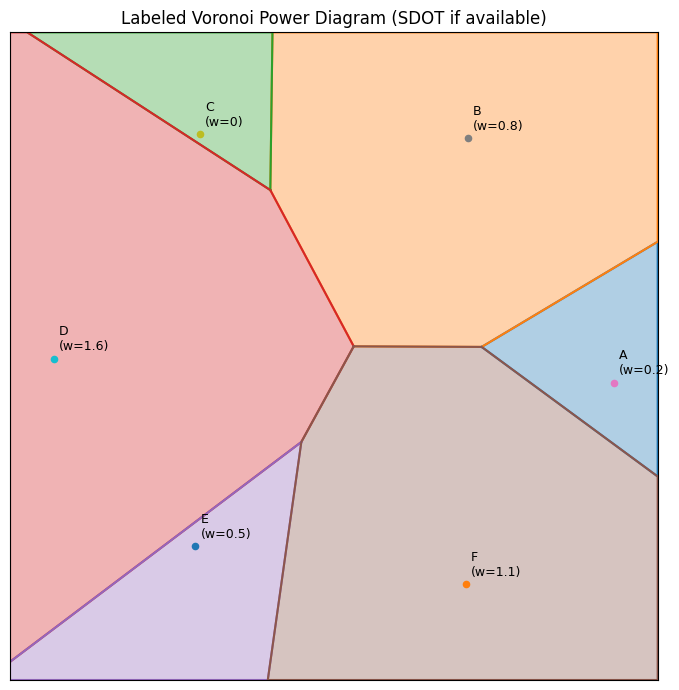

In [4]:

label_weights = {
    "A": 0.2,
    "B": 0.8,
    "C": 0.0,
    "D": 1.6,
    "E": 0.5,
    "F": 1.1,
}
plot_power_diagram(label_weights, seed=3, prefer_sdot=True)